<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Correlation**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis (EDA). You will examine the distribution of the data, identify outliers, and determine the correlation between different columns in the dataset.


## Objectives


In this lab, you will perform the following:


- Identify the distribution of compensation data in the dataset.

- Remove outliers to refine the dataset.

- Identify correlations between various features in the dataset.


## Hands on Lab


##### Step 1: Install and Import Required Libraries


In [12]:
pip install country-converter

Note: you may need to restart the kernel to use updated packages.

In [1]:
# Install the necessary libraries
!pip install pandas
!pip install matplotlib
!pip install seaborn

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 150.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 147.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 183.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 149.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 77.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 165.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]


### Step 2: Load the Dataset


In [2]:
# Load the dataset from the given URL
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(file_url)

# Display the first few rows to understand the structure of the dataset
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 3: Analyze and Visualize Compensation Distribution</h3>


**Task**: Plot the distribution and histogram for `ConvertedCompYearly` to examine the spread of yearly compensation among respondents.


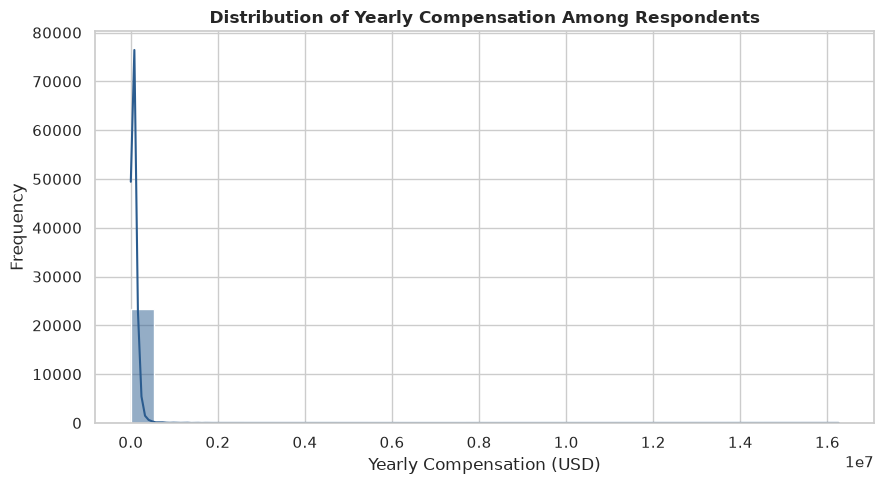

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean visualization theme
sns.set_theme(style="whitegrid")

plt.figure(figsize=(9, 5))

# Plot histogram with smooth KDE line
sns.histplot(
    data=df,
    x="ConvertedCompYearly",
    kde=True,
    color="#2b5c8f",
    bins=30,  # Increased from 10 to reveal distribution shape better
)

plt.title(
    "Distribution of Yearly Compensation Among Respondents",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Yearly Compensation (USD)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

As we can see we can't examine the distribution properly without using a differen scale, so we will use log-trsnsform along the `x-axis`/`ConvertedCompYearly`/ to better visualize our right-skewed data.

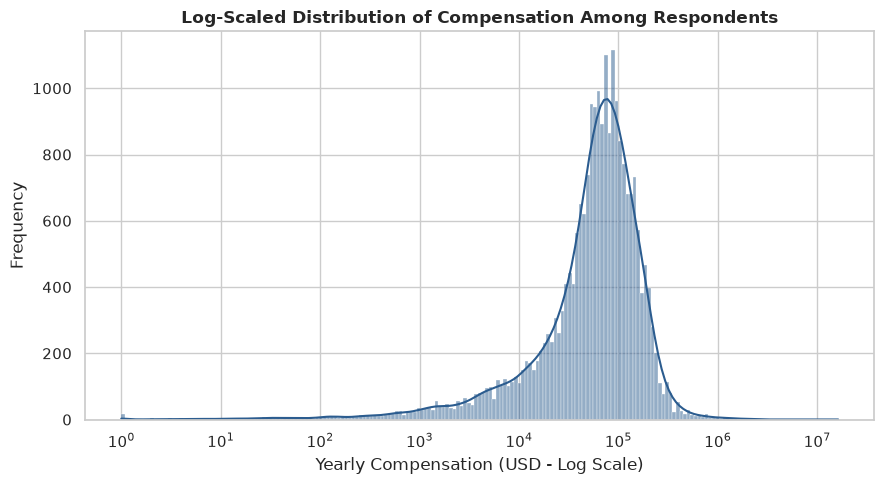

In [4]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="ConvertedCompYearly",
    kde=True,
    log_scale=True,  # Log-transforms x-axis to cleanly visualize right-skewed data
    color="#2b5c8f",
)

plt.title(
    "Log-Scaled Distribution of Compensation Among Respondents",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Yearly Compensation (USD - Log Scale)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

<h3>Step 4: Calculate Median Compensation for Full-Time Employees</h3>


**Task**: Filter the data to calculate the median compensation for respondents whose employment status is "Employed, full-time."


In [8]:
filtered_df = df[df['Employment'].str.contains('Employed, full-time', na=False)]
med_comp = filtered_df['ConvertedCompYearly'].median()
print(f'Median compensation for full-time employees:{med_comp}')

Median compensation for full-time employees:67666.0

<h3>Step 5: Analyzing Compensation Range and Distribution by Country</h3>


Explore the range of compensation in the ConvertedCompYearly column by analyzing differences across countries. Use box plots to compare the compensation distributions for each country to identify variations and anomalies within each region, providing insights into global compensation trends.



First convert Country entries to standardized UNregion values using country_converter, handling special non-geographic response labels like "Nomadic" and missing (NaN) values by remapping or filtering them out before calculating positive compensation medians for log-scale boxplot ordering.

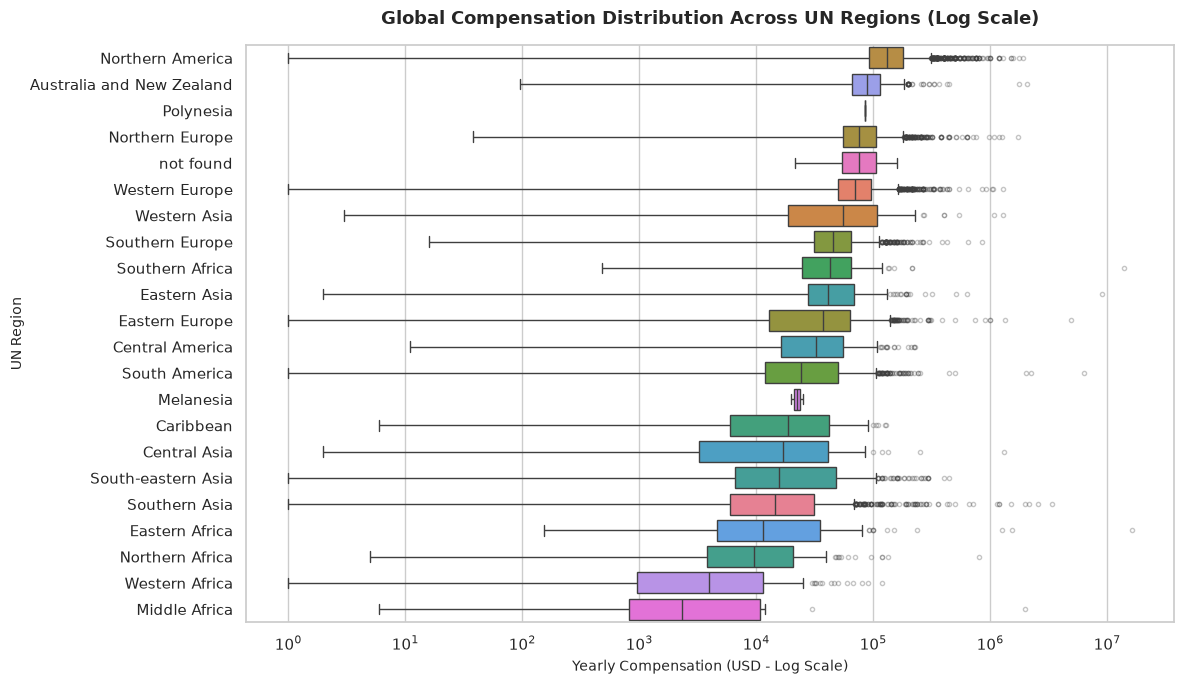

In [22]:
# 1. Clean Country column and map to UNregion
if "Region" not in df.columns:
    cc = coco.CountryConverter()

    # Pre-clean Country column: handle missing values and "Nomadic" entries
    clean_country = (
        df["Country"].fillna("Unknown").replace({"Nomadic": "Nomadic / Remote"})
    )

    # Standardize countries to UNregion (not_found defaults to 'Other/Unknown')
    df["Region"] = cc.convert(
        names=clean_country, to="UNregion", not_found="Other/Unknown"
    )

# 2. Filter valid positive salaries and exclude non-informative region groups
sal_df = df[
    (df["ConvertedCompYearly"] > 0)
    & df["ConvertedCompYearly"].notna()
    & df["Region"].notna()
    & (~df["Region"].isin(["not_found", "Other/Unknown"]))
].copy()

# 3. Sort regions by median compensation for structured visual ordering
region_order = (
    sal_df.groupby("Region")["ConvertedCompYearly"]
    .median()
    .sort_values(ascending=False)
    .index
)

# 4. Generate macro-level regional boxplot
plt.figure(figsize=(12, 7))
sns.boxplot(
    data=sal_df,
    y="Region",
    x="ConvertedCompYearly",
    order=region_order,
    hue="Region",
    flierprops=dict(marker="o", color="red", alpha=0.3, markersize=3),
)

plt.xscale("log")  # Log scale handles global income disparities cleanly
plt.title(
    "Global Compensation Distribution Across UN Regions (Log Scale)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Yearly Compensation (USD - Log Scale)", fontsize=10)
plt.ylabel("UN Region", fontsize=10)
plt.tight_layout()
plt.show()

We select a targeted group of key tech hubs (e.g., US, Germany, India, Brazil) alongside Bulgaria to examine market-specific ranges, median benchmarks, and local outlier characteristics.

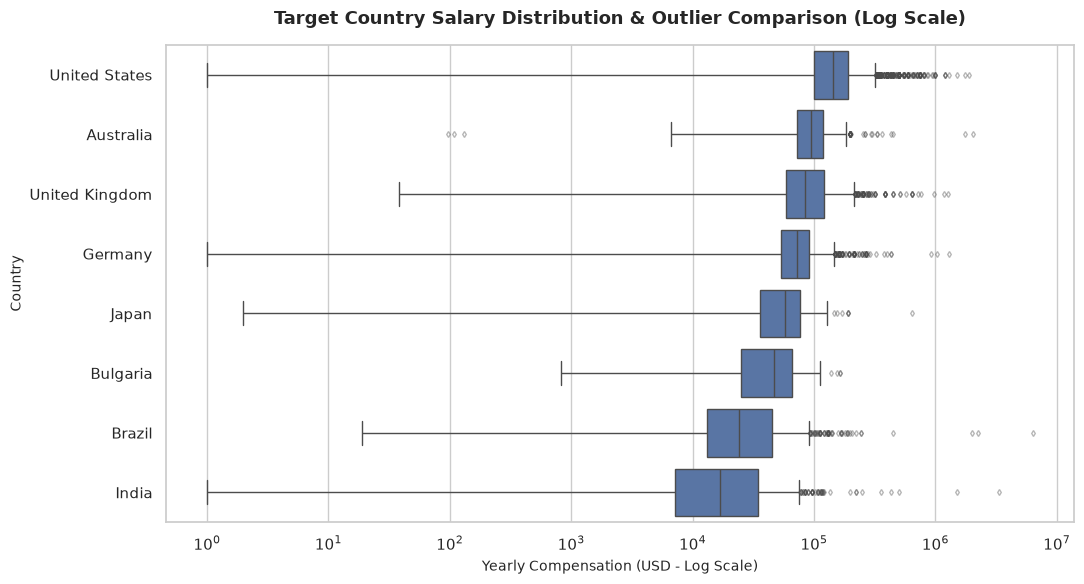

In [26]:
# Define target high-interest countries
target_countries = [
    "United States of America",
    "Germany",
    "United Kingdom of Great Britain and Northern Ireland",
    "Bulgaria",
    "India",
    "Brazil",
    "Japan",
    "Australia",
]

# Standardize names if using country_converter output or raw SO names
target_mask = sal_df["Country"].isin(target_countries) | sal_df[
    "Country"
].str.contains("United States|Bulgaria|Germany|India|Brazil|Japan|Australia")

micro_df = sal_df[target_mask].copy()
# Generate short names via coco, then apply explicit overrides for key hubs
micro_df["Country_Short"] = cc.convert(names=micro_df["Country"].fillna("Unknown"), to="name_short", not_found="Unknown")

# Order boxplots by median compensation
country_order = (
    micro_df.groupby("Country_Short")["ConvertedCompYearly"]
    .median()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(11, 6))
ax = sns.boxplot(
    data=micro_df,
    y="Country_Short",
    x="ConvertedCompYearly",
    order=country_order,
    flierprops=dict(marker="d", color="black", alpha=0.4, markersize=3),
)

plt.xscale("log")
plt.title(
    "Target Country Salary Distribution & Outlier Comparison (Log Scale)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Yearly Compensation (USD - Log Scale)", fontsize=10)
plt.ylabel("Country", fontsize=10)
plt.tight_layout()
plt.show()

We compute summary statistics (sample size, median, IQR, mean, and standard deviation) for Bulgaria in direct comparison to major tech anchor markets to support the visual plots with precise data.

In [18]:
# Summary statistics for Bulgaria vs US vs Germany
comparison_countries = ["Bulgaria", "Germany", "United States of America"]

summary_table = (
    sal_df[sal_df["Country"].isin(comparison_countries)]
    .groupby("Country")["ConvertedCompYearly"]
    .agg(
        Sample_Size="count",
        Median_USD="median",
        IQR_USD=lambda x: x.quantile(0.75) - x.quantile(0.25),
        Mean_USD="mean",
        Std_USD="std",
    )
    .round(2)
)

print("=== Country Compensation Baseline Summary ===")
display(summary_table)

=== Country Compensation Baseline Summary ===

,Sample_Size,Median_USD,IQR_USD,Mean_USD,Std_USD
Country,,,,,
Bulgaria,110,46959.0,40780.0,49034.79,33411.42
Germany,2046,73036.0,37592.0,77054.55,56449.17
United States of America,4677,143000.0,89000.0,161072.34,109920.15


<h3>Step 6: Removing Outliers from the Dataset</h3>


**Task**: Create a new DataFrame by removing outliers from the `ConvertedCompYearly` column to get a refined dataset for correlation analysis.


We calculate the interquartile range (IQR) for positive ConvertedCompYearly entries and define an upper bound cutoff at $Q_3 + 3.0 \times \text{IQR}$. We then construct a refined DataFrame (df_no_iqr_outliers) that excludes extreme compensation outliers while keeping rows with missing salary values intact to prevent unintentional row drops.

In [27]:
# 1. Calculate IQR and 3.0x upper bound on valid positive salary entries
sal_series = df.loc[df["ConvertedCompYearly"] > 0, "ConvertedCompYearly"]

Q1 = sal_series.quantile(0.25)
Q3 = sal_series.quantile(0.75)
IQR = Q3 - Q1
upper_threshold_iqr = Q3 + (3.0 * IQR)

# 2. Filter mask: Keep records <= threshold OR where salary is NaN
clean_mask = (df["ConvertedCompYearly"] <= upper_threshold_iqr) | df[
    "ConvertedCompYearly"
].isna()

# 3. Create refined DataFrame for downstream correlation analysis
df_no_iqr_outliers = df[clean_mask].copy()

# 4. Validation Report
print("=== Refined Dataset Outlier Truncation Summary ===")
print(f"Upper 3.0x IQR Cutoff:  ${upper_threshold_iqr:,.2f}")
print(f"Original Row Count:    {len(df):,}")
print(f"Outliers Removed:       {(~clean_mask).sum():,}")
print(f"Refined Row Count:     {len(df_no_iqr_outliers):,}")
print(f"Sample Retention Rate: {len(df_no_iqr_outliers)/len(df)*100:.2f}%")

=== Refined Dataset Outlier Truncation Summary ===
Upper 3.0x IQR Cutoff:  $333,750.00
Original Row Count:    65,437
Outliers Removed:       316
Refined Row Count:     65,121
Sample Retention Rate: 99.52%

<h3>Step 7: Finding Correlations Between Key Variables</h3>


**Task**: Calculate correlations between `ConvertedCompYearly`, `WorkExp`, and `JobSatPoints_1`. Visualize these correlations with a heatmap.


We extract ConvertedCompYearly, WorkExp, and JobSatPoints_1 from the refined dataset (df_no_iqr_outliers) to compute the Pearson correlation matrix across pairwise non-null values. We then plot an annotated Seaborn heatmap using a diverging colormap with explicit range bounds (-1.0 to 1.0) to cleanly visualize linear relationships.

In [31]:
## Write your code here
target_cols = ['ConvertedCompYearly', 'WorkExp', 'JobSatPoints_1']
df_heat = df_no_iqr_outliers[target_cols].corr(method='pearson')
display(df_heat)

,ConvertedCompYearly,WorkExp,JobSatPoints_1
ConvertedCompYearly,1.000000,0.401389,-0.050437
WorkExp,0.401389,1.000000,-0.027439
JobSatPoints_1,-0.050437,-0.027439,1.000000


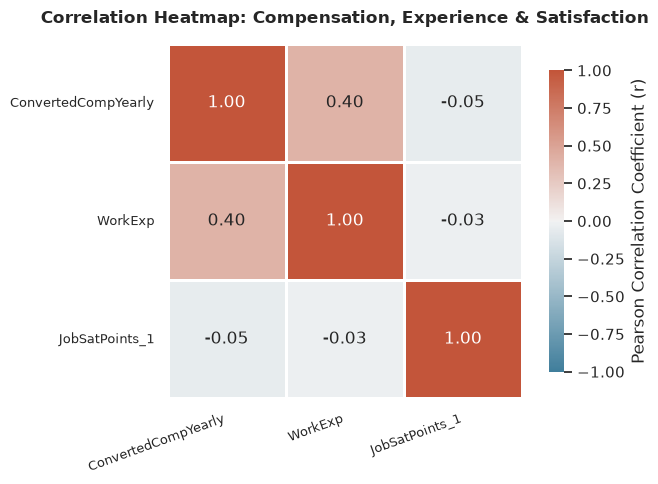

In [32]:
sns.set_theme(style="white", font="sans-serif")
plt.figure(figsize=(7, 5))
sns.heatmap(
    df_heat,
    annot=True,
    fmt=".2f",
    cmap=sns.diverging_palette(230, 20, as_cmap=True),
    vmin=-1.0,
    vmax=1.0,
    center=0,
    square=True,
    linewidths=0.8,
    cbar_kws={
        "shrink": 0.85,
        "label": "Pearson Correlation Coefficient (r)",
    },
)

plt.title(
    "Correlation Heatmap: Compensation, Experience & Satisfaction",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
plt.xticks(rotation=20, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

<h3>Step 8: Scatter Plot for Correlations</h3>


**Task**: Create scatter plots to examine specific correlations between `ConvertedCompYearly` and `WorkExp`, as well as between `ConvertedCompYearly` and `JobSatPoints_1`.


We create a 1x2 grid of scatter plots using Seaborn's regplot to visually examine the relationship between ConvertedCompYearly and work experience (WorkExp), as well as job satisfaction (JobSatPoints_1). Adding a trendline ($\text{OIS}$ regression) helps highlight whether a linear relationship exists despite individual data variance.

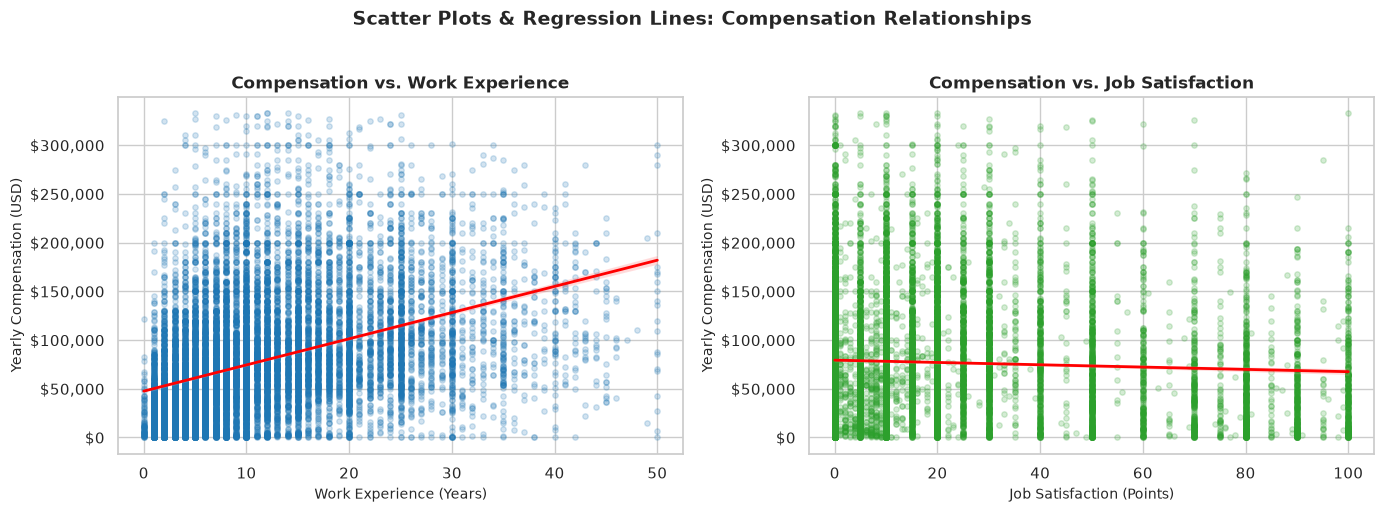

In [35]:
sns.set_theme(style="whitegrid", font="sans-serif")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(
    data=df_no_iqr_outliers,
    x="WorkExp",
    y="ConvertedCompYearly",
    ax=ax1,
    scatter_kws={"alpha": 0.2, "s": 15, "color": "#1f77b4"},
    line_kws={"color": "red", "linewidth": 2},
)
ax1.set_title(
    "Compensation vs. Work Experience", fontsize=12, fontweight="bold"
)
ax1.set_xlabel("Work Experience (Years)", fontsize=10)
ax1.set_ylabel("Yearly Compensation (USD)", fontsize=10)
ax1.yaxis.set_major_formatter("${x:,.0f}")

sns.regplot(
    data=df_no_iqr_outliers,
    x="JobSatPoints_1",
    y="ConvertedCompYearly",
    ax=ax2,
    scatter_kws={"alpha": 0.2, "s": 15, "color": "#2ca02c"},
    line_kws={"color": "red", "linewidth": 2},
)
ax2.set_title(
    "Compensation vs. Job Satisfaction", fontsize=12, fontweight="bold"
)
ax2.set_xlabel("Job Satisfaction (Points)", fontsize=10)
ax2.set_ylabel("Yearly Compensation (USD)", fontsize=10)
ax2.yaxis.set_major_formatter("${x:,.0f}")

plt.suptitle(
    "Scatter Plots & Regression Lines: Compensation Relationships",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

<h3>Summary</h3>


In this lab, you practiced essential skills in correlation analysis by:

- Examining the distribution of yearly compensation with histograms and box plots.
- Detecting and removing outliers from compensation data.
- Calculating correlations between key variables such as compensation, work experience, and job satisfaction.
- Visualizing relationships with scatter plots and heatmaps to gain insights into the associations between these features.

By following these steps, you have developed a solid foundation for analyzing relationships within the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
